# GEOG5003M Final Assignment (Template)

Student ID number:202000175

GitHub repo link:

Word count limit= 1,500 words max (markdown cells only, excluding readme)

1. Data Sources & Initial Description

In [82]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
!pip install contextily
!pip install geoplot
!pip install git+https://github.com/pmdscully/geo_northarrow.git

  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-38j5czg5
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-38j5czg5
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [118]:
# read in required packages
import pandas as pd
import os
import numpy as np
import zipfile
import geopandas as gpd
import contextily as ctx
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from geo_northarrow import add_north_arrow
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

1.1 Data Acquisition and Importing

In [85]:
# LSOA 2011 Boundaries (ONS)
# data acquired from ONS, downloaded from:
# https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Lower_layer_Super_Output_Areas_Dec_2011_Boundaries_Full_Clipped_BFC_EW_V3_2022/FeatureServer/replicafilescache/Lower_layer_Super_Output_Areas_Dec_2011_Boundaries_Full_Clipped_BFC_EW_V3_2022_-6949377563852267737.zip
######## co-pilot############
# Prompt"how to unzip downloaded zip file and find shapefile among all files"
# saved in MyDrive, path:
zip_lsoa="/content/drive/MyDrive/air_pollution_project/Lower_layer_Super_Output_Areas_Dec_2011_Boundaries_Full_Clipped_BFC_EW_V3_2022_-6949377563852267737.zip"
# unzip path
dir_lsoa="/content/drive/MyDrive/air_pollution_project/LSOA_2011"
os.makedirs(dir_lsoa,exist_ok=True)
### creat a unzip path, and if directory exists, then no error
# unzip
with zipfile.ZipFile(zip_lsoa,"r") as z:
    z.extractall(dir_lsoa)
### open LSOA boundary zip file, unzip all files into dir_lsoa,
### use 'with' to ensure all files are correctly closed after decompression
# read shape file
lsoa_shp=[f for f in os.listdir(dir_lsoa) if f.endswith(".shp")][0]
lsoa=gpd.read_file(os.path.join(dir_lsoa,lsoa_shp))
### traverse all .shp files, and take the first one as the main file
### assume only one LSOA shpefile in this directory
#############################

# NO2 2019 concentrations (DEFRA)
# data accuqired from UK-DEFRA, downloaded from:
# https://uk-air.defra.gov.uk/datastore/pcm/aqd2019_baseyear_shapefile_2019.zip
######## co-pilot############
# same prompts with above
# saved in MyDirve, path:
zip_no2="/content/drive/MyDrive/air_pollution_project/aqd2019_baseyear_shapefile_2019.zip"
# unzip path
dir_no2="/content/drive/MyDrive/air_pollution_project/NO2_2019"
# unzip
with zipfile.ZipFile(zip_no2,"r") as z:
    z.extractall(dir_no2)
# read shape file
no2_shp=[f for f in os.listdir(dir_no2) if f.endswith(".shp")][0]
no2=gpd.read_file(os.path.join(dir_no2,no2_shp))
#############################

# IMD 2019 data
# data accuqired from GOV.UK, downloaded from:
# https://assets.publishing.service.gov.uk/media/5dc407b440f0b6379a7acc8d/File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv
# import IMD data
imd=pd.read_csv("/content/drive/MyDrive/air_pollution_project/File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv")

Lower Layer Super Output Area (LSOA) boundaries (2011) were obtained from the UK Office for National Statistics and used as the spatial framework for analysis. Annual mean NO₂ data for 2019 were sourced from DEFRA, while deprivation data were sourced from the UK Government, represented using IMD 2019 deciles linked to LSOAs via unique codes.

1.2 Raw Data Description

1.2.1 LSOA Data

In [86]:
# Explore Raw LSOA Data
print(lsoa.shape)
lsoa.head()

(34753, 9)


,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,geometry
0,E01000001,City of London 001A,532123,181632,-0.097140,51.5182,2635.767993,eaf9e4b8-fcc1-4cae-a46c-22c8a43ff39b,"POLYGON ((532151.537 181867.433, 532152.5 1818..."
1,E01000002,City of London 001B,532480,181715,-0.091970,51.5188,2707.881853,4434ca6e-e270-4e88-b3eb-4cfb37f62490,"POLYGON ((532634.497 181926.016, 532632.048 18..."
2,E01000003,City of London 001C,532239,182033,-0.095320,51.5217,1224.638192,d0ff9760-86dc-40da-ad33-3b1dc987ef04,"POLYGON ((532153.703 182165.155, 532158.25 182..."
3,E01000005,City of London 001E,533581,181283,-0.076270,51.5147,2275.805348,474caa9f-a6e3-4de2-8bc1-2f5b0da40271,"POLYGON ((533619.062 181402.364, 533639.868 18..."
4,E01000006,Barking and Dagenham 016A,544994,184274,0.089317,51.5387,1966.092607,ff2bc9a6-9e26-4415-9cec-eaea2c0a4f54,"POLYGON ((545126.852 184310.838, 545145.213 18..."


In [87]:
lsoa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34753 entries, 0 to 34752
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LSOA11CD    34753 non-null  object  
 1   LSOA11NM    34753 non-null  object  
 2   BNG_E       34753 non-null  int64   
 3   BNG_N       34753 non-null  int64   
 4   LONG_       34753 non-null  float64 
 5   LAT         34753 non-null  float64 
 6   Shape_Leng  34753 non-null  float64 
 7   GlobalID    34753 non-null  object  
 8   geometry    34753 non-null  geometry
dtypes: float64(3), geometry(1), int64(2), object(3)
memory usage: 2.4+ MB


In [88]:
# check NA
lsoa.isna().sum()

,0
LSOA11CD,0
LSOA11NM,0
BNG_E,0
BNG_N,0
LONG_,0
LAT,0
Shape_Leng,0
GlobalID,0
geometry,0


In [89]:
#check CRS
lsoa.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

The raw LSOA boundary dataset contains 34,753 polygons covering England and Wales, with complete attribute and geometry information and no missing values.
The data are provided in the British National Grid Projection (EPSG:27700).

1.2.2 NO2 Data

In [90]:
# Explore Raw NO2 Data
print(no2.shape)
no2.head()

(151567, 12)


,ROADNUMBER,CLASS,FORMOFWAY,CENSUS_ID,NI_GB,LENGTH,DFT_CP,URBAN,ZAGGLOM_ID,ZAGGLOM_NA,RNO22019,geometry
0,A435,A Road,Roundabout,802037188.0,GB,8.586591,37188.0,1,2.0,West Midlands Urban Area,25.93621,"LINESTRING (407779.267 278524.25, 407775.95 27..."
1,M4,Motorway,Collapsed Dual Carriageway,802077075.0,GB,17.549873,77075.0,1,41.0,South Wales,39.55719,"LINESTRING (276168.088 190467.226, 276182.65 1..."
2,M4,Motorway,Collapsed Dual Carriageway,802077075.0,GB,457.003202,77075.0,1,27.0,Swansea Urban Area,39.55719,"LINESTRING (275788.92 190722.34, 275985.79 190..."
3,A5027,A Road,Collapsed Dual Carriageway,802017653.0,GB,1.658493,17653.0,1,20.0,Birkenhead Urban Area,26.21796,"LINESTRING (331138.28 390353.84, 331137.69 390..."
4,A3024,A Road,Collapsed Dual Carriageway,802046963.0,GB,42.949274,46963.0,1,19.0,Southampton Urban Area,31.19951,"LINESTRING (443436.55 113266.74, 443425.02 113..."


In [91]:
no2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 151567 entries, 0 to 151566
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   ROADNUMBER  151521 non-null  object  
 1   CLASS       151503 non-null  object  
 2   FORMOFWAY   150642 non-null  object  
 3   CENSUS_ID   151567 non-null  float64 
 4   NI_GB       151567 non-null  object  
 5   LENGTH      151567 non-null  float64 
 6   DFT_CP      151567 non-null  float64 
 7   URBAN       151567 non-null  int32   
 8   ZAGGLOM_ID  151567 non-null  float64 
 9   ZAGGLOM_NA  151567 non-null  object  
 10  RNO22019    151567 non-null  float64 
 11  geometry    151567 non-null  geometry
dtypes: float64(5), geometry(1), int32(1), object(5)
memory usage: 13.3+ MB


In [92]:
no2.describe()

,CENSUS_ID,LENGTH,DFT_CP,URBAN,ZAGGLOM_ID,RNO22019
count,1.515670e+05,151567.000000,151567.000000,151567.0,151567.000000,151567.000000
mean,7.971569e+08,83.119545,45874.938291,1.0,18.544828,26.121729
std,6.239495e+07,132.313928,27302.974954,0.0,14.614242,8.052717
min,9.021030e+05,0.002360,0.000000,1.0,1.000000,3.958550
25%,8.020209e+08,27.071468,20901.000000,1.0,3.000000,20.672850
50%,8.020466e+08,51.061675,46553.000000,1.0,22.000000,24.929290
75%,8.020740e+08,95.301739,73961.000000,1.0,32.000000,30.334710
max,8.021000e+08,8518.873998,99967.000000,1.0,43.000000,76.751280


In [93]:
# check no2 missing value
no2.isna().sum()

,0
ROADNUMBER,46
CLASS,64
FORMOFWAY,925
CENSUS_ID,0
NI_GB,0
LENGTH,0
DFT_CP,0
URBAN,0
ZAGGLOM_ID,0
ZAGGLOM_NA,0


In [94]:
# Check NO2 data CRS
no2.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

The raw NO₂ dataset contains 151,567 spatial features representing road-level segments across England and Wales, including complete geometry information and no missing values for the NO₂ concentration variable(RNO22019), and it is also provided in EPSG:27700 Projection.

1.2.3 Deprivation Data

In [95]:
# Explore Raw IMD Data
print(imd.shape)
imd.head()

(32844, 57)


,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,17318,6,2.207,162,1,1350,146,759,445,804
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,25218,8,1.769,849,1,1121,229,692,200,683
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,...,14745,5,0.969,4368,2,2040,522,1297,221,1285


In [96]:
imd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 57 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   LSOA code (2011)                                                                                    32844 non-null  object 
 1   LSOA name (2011)                                                                                    32844 non-null  object 
 2   Local Authority District code (2019)                                                                32844 non-null  object 
 3   Local Authority District name (2019)                                                                32844 non-null  object 
 4   Index of Multiple Deprivation (IMD) Score                                                           32844 non-nu

In [97]:
imd.describe()

,Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score",...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
count,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,...,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000,32844.000000
mean,21.669393,16422.499208,5.500122,0.128166,16422.498478,5.500122,0.099921,16422.498295,5.500122,21.691084,...,16422.499574,5.500122,-0.000001,16422.499756,5.500122,1666.307514,316.802156,965.482737,384.022622,971.587839
std,15.332229,9481.390454,2.872325,0.093539,9481.389874,2.872325,0.067436,9481.390049,2.872325,18.607562,...,9481.390525,2.872325,0.821500,9481.390538,2.872325,363.622458,117.761896,306.563460,151.874176,304.150940
min,0.541000,1.000000,1.000000,0.003000,1.000000,1.000000,0.002000,1.000000,1.000000,0.013000,...,1.000000,1.000000,-3.749000,1.000000,1.000000,523.000000,17.000000,310.000000,15.000000,329.000000
25%,9.913750,8211.750000,3.000000,0.056000,8211.750000,3.000000,0.050000,8211.750000,3.000000,7.360000,...,8211.750000,3.000000,-0.582000,8211.750000,3.000000,1446.000000,238.000000,784.000000,276.000000,793.000000
50%,17.647500,16422.500000,5.500000,0.099000,16422.500000,5.500000,0.080000,16422.500000,5.500000,16.180500,...,16422.500000,5.500000,-0.068000,16422.500000,5.500000,1598.000000,298.000000,907.000000,367.000000,911.000000
75%,29.583000,24633.250000,8.000000,0.178000,24633.250000,8.000000,0.133000,24633.250000,8.000000,30.906500,...,24633.250000,8.000000,0.519000,24633.250000,8.000000,1800.000000,372.000000,1074.000000,471.000000,1076.000000
max,92.735000,32844.000000,10.000000,0.609000,32844.000000,10.000000,0.534000,32844.000000,10.000000,99.446000,...,32844.000000,10.000000,3.310000,32844.000000,10.000000,9551.000000,1632.000000,8608.000000,1372.000000,8589.000000


In [98]:
# check imd missing value
imd.isna().sum()

,0
LSOA code (2011),0
LSOA name (2011),0
Local Authority District code (2019),0
Local Authority District name (2019),0
Index of Multiple Deprivation (IMD) Score,0
Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),0
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),0
Income Score (rate),0
Income Rank (where 1 is most deprived),0
Income Decile (where 1 is most deprived 10% of LSOAs),0


The IMD 2019 dataset contains 32,844 LSOAs across England, with 57 socio-economic attributes including the overall IMD score, rank, decile, and other domain-level indicators, with no missing values.
Therefore, IMD data were suitable for direct linkage to LSOA boundary geometries using the LSOA code attribute.

2. Data Cleaning & Pre-processing

2.1 Subsetting Data to Study Area

2.1.1 LSOA Spatial Subsetting

In [99]:
# extract manchester LSOA
mcr_lsoa=lsoa[lsoa["LSOA11NM"].str.contains("Manchester")]
# check
print(mcr_lsoa.shape)
print(mcr_lsoa.crs)
mcr_lsoa.head()

(282, 9)
EPSG:27700


,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,geometry
5196,E01005061,Manchester 018A,386335,397111,-2.20732,53.4706,5196.009141,472c63b2-d9d9-4b27-834a-20bb256f8175,"POLYGON ((386894.4 397240.187, 386906.906 3972..."
5197,E01005062,Manchester 018B,385120,396466,-2.22559,53.4647,6132.029869,c7d5be0c-553e-4736-9807-1543ace218ff,"POLYGON ((384601 397195, 384603 397184, 384604..."
5198,E01005063,Manchester 018C,385853,396436,-2.21455,53.4645,5365.459117,6c19adc0-3098-46f8-83f2-262cb2a2c6af,"POLYGON ((386140.989 396808.79, 386127.286 396..."
5199,E01005065,Manchester 018D,385314,397132,-2.22270,53.4707,5029.650902,22f4fc35-ad1f-4163-addf-36b692101ded,"POLYGON ((385738 397442, 385739 397430, 385739..."
5200,E01005066,Manchester 018E,384428,397188,-2.23605,53.4712,2621.399670,96a46ea0-f7cd-459e-b8fc-94d4829a715c,"POLYGON ((384850 397432, 384859 397413, 384860..."


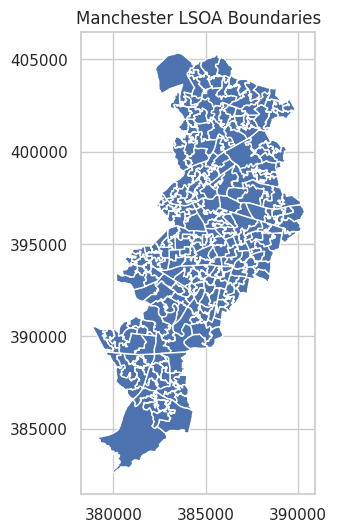

In [100]:
# simply draw manchester lsoa map
mcr_lsoa.plot(figsize=(6,6))
plt.title("Manchester LSOA Boundaries")
plt.show()

Manchester was selected as the study area for this analysis.

LSOAs within Manchester were extracted based on the LSOA name attribute from the national LSOA boundary dataset, resulting in a subset of 282 LSOAs, with a preliminary map produced to confirm the correctness.


2.1.2 Spatial Subsetting of NO2 Data to Study Area

In [101]:
# extract needed data and rename
no2_clean=no2[[
    "RNO22019",
    "geometry"
]]
# rename
no2_clean=no2_clean.rename(columns={
    "RNO22019":"NO2_concentration",
    })
# show
print(no2_clean.head())
no2_clean.info()

   NO2_concentration                                           geometry
0           25.93621  LINESTRING (407779.267 278524.25, 407775.95 27...
1           39.55719  LINESTRING (276168.088 190467.226, 276182.65 1...
2           39.55719  LINESTRING (275788.92 190722.34, 275985.79 190...
3           26.21796  LINESTRING (331138.28 390353.84, 331137.69 390...
4           31.19951  LINESTRING (443436.55 113266.74, 443425.02 113...
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 151567 entries, 0 to 151566
Data columns (total 2 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   NO2_concentration  151567 non-null  float64 
 1   geometry           151567 non-null  geometry
dtypes: float64(1), geometry(1)
memory usage: 2.3 MB


In [102]:
# clip NO2 data to Manchester LSOA level
no2_mcr=gpd.overlay(no2_clean,mcr_lsoa,how="intersection")
# keep only necessary columns
no2_mcr=no2_mcr[["LSOA11CD","NO2_concentration","geometry"]]
# show
print(no2_mcr.shape)
no2_mcr.head()

(2557, 3)


/usr/local/lib/python3.12/dist-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 4 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


,LSOA11CD,NO2_concentration,geometry
0,E01033656,30.11848,"LINESTRING (383660.24 397275.14, 383663.12 397..."
1,E01005245,34.73922,"LINESTRING (383821.71 395697.08, 383821.71 395..."
2,E01033682,31.57497,"LINESTRING (383086.74 397338.68, 383074.87 397..."
3,E01033658,29.93199,"LINESTRING (384169.3 399027.58, 384168.52 3990..."
4,E01033679,27.98648,"LINESTRING (385586 400592, 385598 400586.5, 38..."


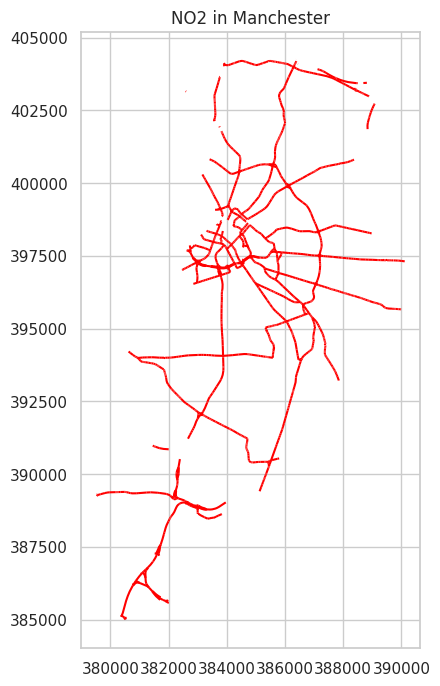

In [103]:
# simply draw NO2 concentration in Manchester
fig,ax=plt.subplots(1,figsize=(8,8))
# NO2
no2_mcr.plot(ax=ax,color="red",label="NO2 roads")
ax.set_title("NO2 in Manchester")
# show
plt.show()

The NO₂ dataset was simplified to retain only concentration values and road geometries, and spatially subset to Manchester using an intersection overlay with LSOA boundaries.
This ensured that all subsequent NO₂ analysis was restricted to the study area.


2.2 Aggregating NO2 to LSOA Level

2.2.1 Establishing Spatial Relationship

In [104]:
# buffer NO2 line to align polygon
no2_mcr=no2_mcr.to_crs(27700)
# buffer 50m
no2_mcr["geometry"]=no2_mcr.buffer(50)
# check result
print(no2_mcr.head())
no2_mcr.info()


    LSOA11CD  NO2_concentration  \
0  E01033656           30.11848   
1  E01005245           34.73922   
2  E01033682           31.57497   
3  E01033658           29.93199   
4  E01033679           27.98648   

                                            geometry  
0  POLYGON ((383709.425 397286.933, 383712.305 39...  
1  POLYGON ((383871.71 395696.92, 383871.469 3956...  
2  POLYGON ((383119.984 397292.282, 383108.114 39...  
3  POLYGON ((384209.55 398997.885, 384206.552 398...  
4  POLYGON ((385618.833 400631.953, 385630.833 40...  
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   LSOA11CD           2557 non-null   object  
 1   NO2_concentration  2557 non-null   float64 
 2   geometry           2557 non-null   geometry
dtypes: float64(1), geometry(1), object(1)
memory usage: 60.1+ KB


In [105]:
# Overlay NO2 buffer polygon and Manchester LSOA
no2_inter=gpd.overlay(no2_mcr,mcr_lsoa,how="intersection")
# keep only necessary columns
no2_inter=no2_inter[["LSOA11CD_1","NO2_concentration","geometry"]]
# check
print(no2_inter.head())
no2_inter.info()

  LSOA11CD_1  NO2_concentration  \
0  E01033656           30.11848   
1  E01033656           30.11848   
2  E01005245           34.73922   
3  E01033682           31.57497   
4  E01033682           31.57497   

                                            geometry  
0  POLYGON ((383712.305 397279.863, 383713.931 39...  
1  POLYGON ((383621.766 397237.689, 383619.695 39...  
2  POLYGON ((383871.469 395692.019, 383870.749 39...  
3  POLYGON ((383041.442 397243.886, 383037.124 39...  
4  POLYGON ((383108.114 397267.442, 383105.783 39...  
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5314 entries, 0 to 5313
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   LSOA11CD_1         5314 non-null   object  
 1   NO2_concentration  5314 non-null   float64 
 2   geometry           5314 non-null   geometry
dtypes: float64(1), geometry(1), object(1)
memory usage: 124.7+ KB


In [106]:
# rename
no2_inter=no2_inter.rename(columns={
    "LSOA11CD_1":"LSOA11CD"
})
# check
no2_inter.head()

,LSOA11CD,NO2_concentration,geometry
0,E01033656,30.11848,"POLYGON ((383712.305 397279.863, 383713.931 39..."
1,E01033656,30.11848,"POLYGON ((383621.766 397237.689, 383619.695 39..."
2,E01005245,34.73922,"POLYGON ((383871.469 395692.019, 383870.749 39..."
3,E01033682,31.57497,"POLYGON ((383041.442 397243.886, 383037.124 39..."
4,E01033682,31.57497,"POLYGON ((383108.114 397267.442, 383105.783 39..."


The road-level NO₂ data were transformed from lines into polygon features using a 50-meter buffer.

These distances decay non-linearly and reach near-background levels beyond this range[1]. By applying this buffer, the model captures the primary "high-exposure zone" where effects of road emissions are most concentrated, allowing for a more sensible spatial intersection with LSOA boundaries.

The buffer polygons were then intersected with the Manchester LSOA boundaries. This operation associated NO₂ exposure with individual LSOAs wherever buffered road segments overlapped the neighbourhood boundaries.

The result provided the spatial linkage required to aggregate NO₂ concentrations to the LSOA level.

2.2.2 Calculating Mean NO2 Concentration in LSOAs

In [107]:
# calculate the mean value of NO2 and average traffic value in each Manchester LSOA after aggregation
lsoa_no2=(
   no2_inter.groupby("LSOA11CD")[["NO2_concentration"]]
   .mean()
   .reset_index()
)
# rename
lsoa_no2.rename(columns={"NO2_concentration":"mean_no2"},inplace=True)
# check
print(lsoa_no2.head())
lsoa_no2.info()

    LSOA11CD   mean_no2
0  E01005061  29.235041
1  E01005062  27.997568
2  E01005063  27.452328
3  E01005065  30.671978
4  E01005066  34.087862
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LSOA11CD  177 non-null    object 
 1   mean_no2  177 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.9+ KB


NO₂ concentrations were then aggregated to the neighbourhood scale, by calculating the mean concentration for each LSOA, and averaging all associated road-level NO₂ values within that area (using groupby with LSOA code attribute).


After aggregation, mean concentrations were successfully derived for 177 out of 282 Manchester LSOAs. The remaining LSOAs did not contain any intersecting buffered road segments and therefore had no observable road-related NO₂ exposure in the dataset.

Treating unobserved or non-intersecting segments as 'zero' would introduce systematic measurement error and lead to a 'left-censoring' bias, effectively underestimating the true exposure[2].
Therefore, these areas with no mean NO₂ value were excluded from the subsequent analysis to avoid introducing assumptions.

2.3 IMD Data Processing

In [108]:
# extract the needed columns and rename
# extract
imd=imd[[
    "LSOA code (2011)",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)"
]]
# rename
imd=imd.rename(columns={
    "LSOA code (2011)":"LSOA11CD",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)":"imd_decile"
})

In [109]:
# show
print(imd.shape)
print(imd.head())
imd.info()

(32844, 2)
    LSOA11CD  imd_decile
0  E01000001           9
1  E01000002          10
2  E01000003           5
3  E01000005           3
4  E01000006           5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   LSOA11CD    32844 non-null  object
 1   imd_decile  32844 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 513.3+ KB


IMD decile were selected to represent overall neighbourhood-level deprivation, reflecting the multi-dimensional nature of socio-economic disadvantages[3].

As the objective was to assess broad inequality patterns rather than individual deprivation domains, IMD deciles were used in preference to domain-specific indicators.

2.4 Merge All Data

In [110]:
# Merge all LSOA-LEVEL datasets
# LSOA geometry
df=mcr_lsoa[["LSOA11CD","geometry"]]
# mean NO2
df=df.merge(lsoa_no2,on="LSOA11CD",how="left")
# IMD (score + decile)
df=df.merge(imd,on="LSOA11CD",how="left")

# convert IMD Decile type back to category
df["imd_decile"]=df["imd_decile"].astype("category")
# show
print(df.shape)
df.info()

(282, 4)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LSOA11CD    282 non-null    object  
 1   geometry    282 non-null    geometry
 2   mean_no2    177 non-null    float64 
 3   imd_decile  282 non-null    category
dtypes: category(1), float64(1), geometry(1), object(1)
memory usage: 7.4+ KB


In [111]:
# check missing value
df.isna().sum()

,0
LSOA11CD,0
geometry,0
mean_no2,105
imd_decile,0


Manchester LSOA geometries were used as the spatial backbone, with LSOA-level mean NO2 values and IMD deciles merged using left joins.

This resulted in 177 LSOAs with observed mean NO2 values,while remaining missing values reflected the absence of intersecting road segments rather than data gaps.

3. Exploratory Data Analysis

3.1 Descriptive Statistics

In [112]:
# basic descriptive value
df.describe()

,mean_no2
count,177.000000
mean,28.651593
std,3.474012
min,23.357300
25%,26.220280
50%,28.343906
75%,30.162925
max,40.714480


Descriptive statistics were calculated for the LSOA-level mean NO2 concentration in Manchester, with values ranging from approximately 23 to 41 µg/m³ for 177 LSOAs.

3.2 Distribution of Mean NO2 Concentration across Manchester LSOA

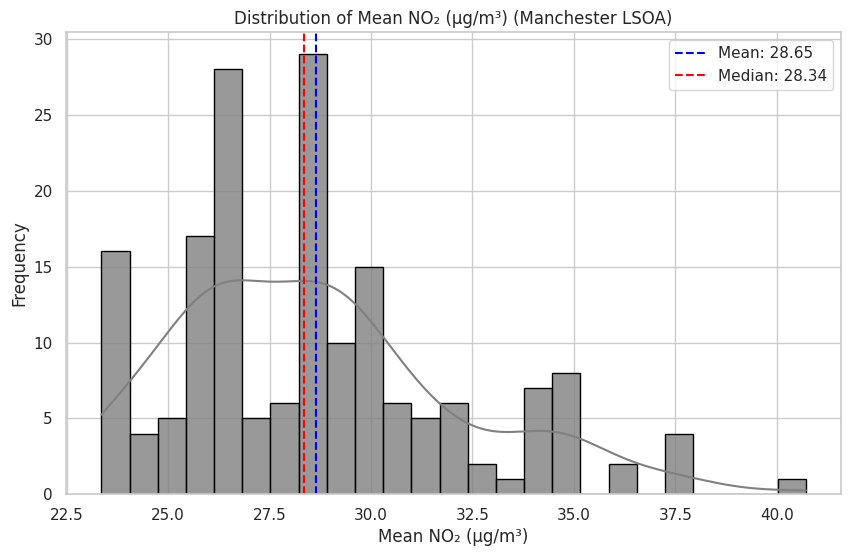

In [113]:
# get mean_no2 and drop null value
no2_mean=df["mean_no2"].dropna()
# draw figure
plt.figure(figsize=(10,6))
# histogram
sns.histplot(
    data=no2_mean,
    bins=25,
    kde=True,
    color="grey",
    alpha=0.8,
    edgecolor="black"
)

#############Co-polit##############
### prompts "how to add mean and median vertical line in a histogram"
# add mean and median vertical line
plt.axvline(      # draw a vertical line  to specify a typical x value position
    no2_mean.mean(), # calculate no2_mean and set as x position
    color="blue",linestyle="--", # set line color(blue) and style(dashes line)
    linewidth=1.5,  # set line width 1.5
    label=f"Mean: {no2_mean.mean():.2f}"
### add lengend for this line,
### f-string: format the mean value to display two decimal places
)
plt.axvline(
    no2_mean.median(), # calculated no2 median value
    color="red",linestyle="--",
    linewidth=1.5,
    label=f"Median: {no2_mean.median():.2f}"
)
#####################################
# add title and axis labels
plt.title("Distribution of Mean NO₂ (µg/m³) (Manchester LSOA)")
plt.xlabel("Mean NO₂ (µg/m³)")
plt.ylabel("Frequency")
# add legend
plt.legend()
# show
plt.show()

A histogram was used to visualize the distribution of mean NO2 concentration across Manchester LSOAs, with vertical lines indicating the mean(blue) and median(red).

The distribution is centered around 28-29 µg/m³, with a small number of high-exposure areas.
The mean and median values are very similar (28.65 & 28.34), indicating a broadly pattern of distribution with limited influence from extreme values.

3.3 NO2 Exposure across IMD deciles

/tmp/ipykernel_8786/843363478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


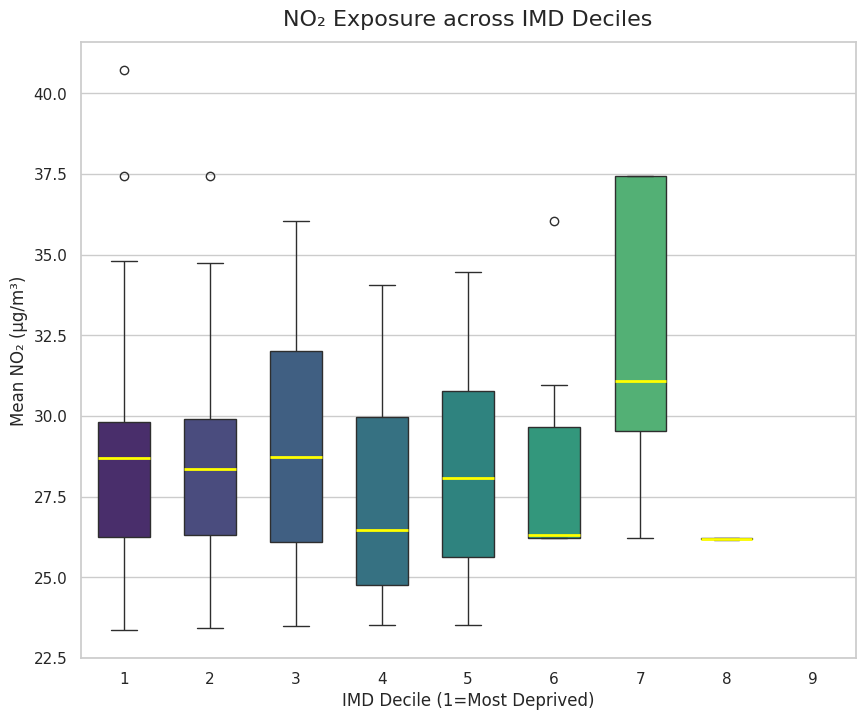

In [114]:
# drop NA
df_plot=df[["mean_no2","imd_decile"]].dropna()
# set theme
sns.set_theme(style="whitegrid")
# draw figure
plt.figure(figsize=(10,8))
# boxplot
sns.boxplot(
    data=df_plot,
    x="imd_decile",
    y="mean_no2",
    palette="viridis",
    width=0.6,
    medianprops={"color":"yellow","linewidth":2}
)
# add title
plt.title("NO₂ Exposure across IMD Deciles",fontsize=16,pad=12)
# add label
plt.xlabel("IMD Decile (1=Most Deprived)",fontsize=12)
plt.ylabel("Mean NO₂ (µg/m³)",fontsize=12)
# show
plt.show()

Boxplots, applied in this study, were used to illustrate the relationship between NO2 (numerical variable) and IMD deciles (categorical variable), providing a robust comparison of pollutant concentrations across different socio-economic level[4], as it highlights central tendency, variability, and outliers in a single view.

Overall, there is no obvious decline in NO2 exposure as deprivation decreases across Manchester LSOAs.
High Exposure in most deprived areas (1-3), with median concentrations consistently around 28.5 and outliers in Decile 1 exceeding 40.
Data in Decile 7 shows a significant non-linear surge, exhibiting the widest interquartile range (26-37.5) and a median of 31, surpassing the levels in the most deprived categories.
Furthermore, data for Decile 8 and the total absence of Deciles 9, which is likely reflecting the absence of observable NO2 exposure of these roads rather than true zero pollution.

Viridis color palette ensures perceptually uniform color progression across IMD deciles while remaining color-blind friendly, improving accessibility and interpretability. Yellow median line is more prominent when viewed against the background color.

4. Simple Modelling & Non-spatial Analysis: Linear Regression between IMD decile and mean NO2 concentration

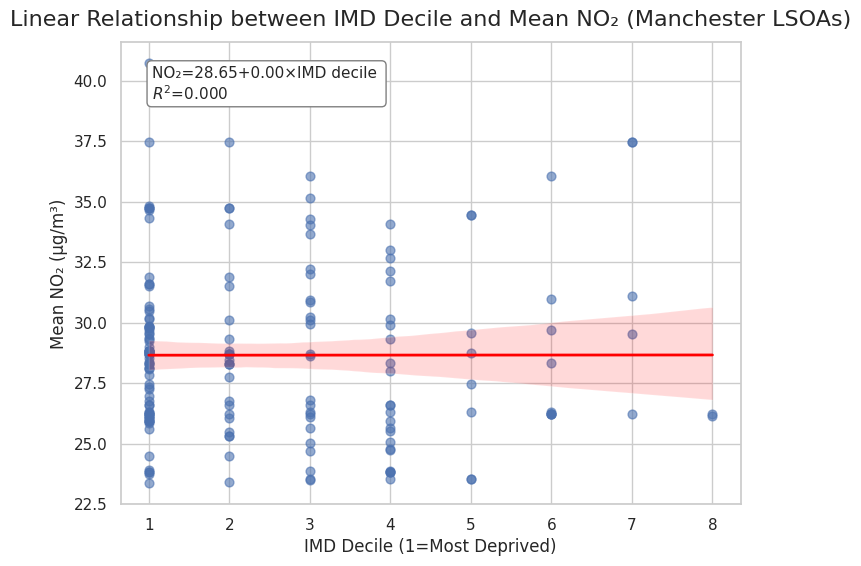

In [115]:
# Prepare data: drop NA and convert to int
df_regplot=df[["mean_no2","imd_decile"]].dropna()
df_regplot["imd_decile"]=df_regplot["imd_decile"].astype(int)
# set theme
sns.set_theme(style="whitegrid")
# draw figure
plt.figure(figsize=(8,6))
# draw regression plot
sns.regplot(
    data=df_regplot,
    x="imd_decile",
    y="mean_no2",
    scatter_kws={"s":40,"alpha":0.6},
    line_kws={"color":"red","linewidth":2}
)
############## Co-pilot ###############
# prompts "how to add slope and R² in a regression plot"
# add Slope and R²
# Define Variables
x=df_regplot["imd_decile"] # extract imd_decile column from df_regplot
y=df_regplot["mean_no2"] # extract mean_no2 value
res=linregress(x,y) # calculate the regression and return an object 'res'

slope=res.slope  # get slope from 'res' result
intercept=res.intercept
### get intercept
### meaningless here （IMD decile start from 1）, but still necessary in a complete regression equation)
r2=res.rvalue**2 # get Pearson's correlation coefficient r, square it and get R²
# draw result above in the map
plt.text(   # add text
    0.05,0.95,
    ### 5% on the left, 95% above (based on axes fraction)
    f"NO₂={intercept:.2f}+{slope:.2f}×IMD decile \n$R^2$={r2:.3f}",
    ### use f-string to generate text dynamically, and to show equation and R²
    ### use \n to devide into 2 rows
    ### define variable as NO₂(mean_no2)
    ### {intercept:.2f}： keep 2 decimals of intercept from 'res.intercept', representing intercept text
    ### {slope:.2f}: keep 2 decimals form 'res.slope', representing slope text
    ### $R^2$={r2:.3f}: $...$ represent the LaTex math grammer,
    ### R^2 means the R², with the value of the formatting variable 'r2' to 3 decimals
    transform=plt.gca().transAxes, # set text axis the current axis, and use Relative axis coordinates
    fontsize=11, # control font size,
    verticalalignment="top", # vertical alignment as top
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey") # ensure text not byond the plot box
)
########################################
# add title
plt.title("Linear Relationship between IMD Decile and Mean NO₂ (Manchester LSOAs)",fontsize=16,pad=12)
# add label
plt.xlabel("IMD Decile (1=Most Deprived)",fontsize=12)
plt.ylabel("Mean NO₂ (µg/m³)",fontsize=12)
# show
plt.show()

A simple linear regression was used to examine the relationship between IMD decile and mean NO2 concentration across Manchester LSOAs, aiming to quantify the relationship between the overall direction and strength of association implied by the EDA rather than to establish a predictive model.

The fitted model has near-zero slope and an R² value close to zero, indicating that IMD decile explains virtually none of the variation in NO2 exposure at this spatial scale.
Data points are widely scattered across all deprivation categories, overlapping between different decile groups, indicating that variability within single decile dominates over any systematic between-decile trend.

For the visualization design, scatter plot with a regression line is to display the predictive value of each LSOA and overall trend, indirectly demonstrating the high degree of dispersion of the scatter and the limited explanatory power of the model.
Adding regression equation and R² value into figure contribute to facilitating interpretation without extra statistical tables, supporting both academic and policy-oriented audiences.

Meanwhile, a neutral color scheme and semi-transparent points were used to minimize visual clutter and ensure readability, while color-blind friendly. Overall, this non-spatial regression visualization aligns with common practices in environmental and public health analysis by clearly communicating weak or null associations without over-interpretation.

5. Spatial Processing: IMD-NO2 Overlay Map (Manchester LSOA)

In [116]:
# convertg CRS to Web Mercator(EPSG:3857) for adding CartoDB.Voyager basemap
df_3857=df.to_crs(epsg=3857)

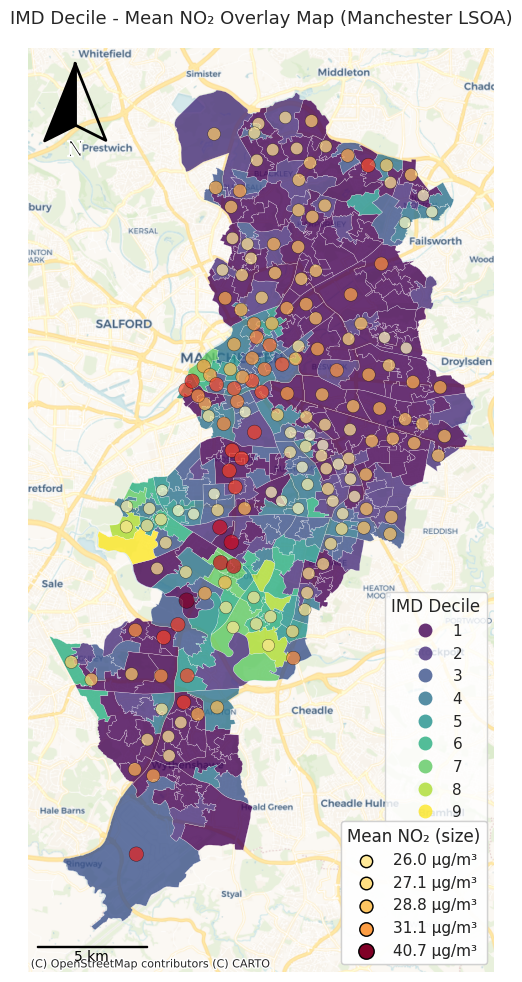

In [119]:
# create centroid for each LSOA in Manchester
df_3857["centroid"]=df_3857.geometry.centroid
# drop NA value
no2_valid=df_3857.dropna(subset=["mean_no2"])

# draw figure
fig,ax=plt.subplots(figsize=(12,12))
# draw base map IMD Decile
imd_plot=df_3857.plot(
    column="imd_decile",
    cmap="viridis",
    linewidth=0.2,
    edgecolor="white",
    alpha=0.8,
    legend=True,
    ax=ax,
)
# draw scatter symbols to represent NO2 value
############## Co-pilot ##############
### prompts "how to create a proportional symbol scatter layer (with dynamic size color matching map) on top of an existing choropleth map ?"
size_symbols=3
### set a normal numerical variable as a zoom factor for the following visualization effect adjustment
# draw scatter to represent NO2 concentration
scatter=ax.scatter(  # create scatter on the axis 'ax' object
    no2_valid.centroid.x,
    no2_valid.centroid.y,
### Extract the x and y coordinate arrays from the same set of geometric center points
### return the centroids of all geometric objects
### mean_no2 are aggregation value in LSOA, not a real point
    s=no2_valid["mean_no2"]*size_symbols,
### set parameter 's' in sactter(), and multiply mean_no2 with size_symbols
### to create the proportianl symbol for each
    c=no2_valid["mean_no2"],
### set the mean_no2 value as the color of scatters
    cmap="YlOrRd",  # color theme
    alpha=0.7,    # transparency
    edgecolor="black",  # add black edge line for each sactter
    linewidth=0.3 # edge line width
)
#########################################

# add base map
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Voyager,crs=df_3857.crs)

# ############ Co-pilot ##############
# prompts "when adding a contextily basemap, the choropleth legend vanished, how to solve"
# save the IMD legend before basemap overwrite
imd_legend=ax.get_legend() # stores the existing IMD choropleth legend
# restore IMD legend after basemap cover
if imd_legend:
#### ensure subsequent legend restoration steps only applied when a legend object exist, avoiding runtime errors
    ax.add_artist(imd_legend)
    ### restore the previously save IMD legend after it has been removed by the basemap rendering.
    imd_legend.set_title("IMD Decile")  # add title
    imd_legend.set_loc("lower right")   # add anchor points to the lower right of the legend frame
    imd_legend.set_bbox_to_anchor((1,0.15),transform=ax.transAxes)
    ### use only set_loc is not enough to control the accurate position, especially more than 1 legend
    ### use relative axis coordinates to ensure consistent placement and preventing overlap with other elements
    ### based on ax.transAxes, place the legend on the right side of the graph, 15% from the bottom
#########################################

############### Co-pilot ##############
### prompts "how to create a proportional symbol scatter layer (with dynamic size color matching map) on top of an existing choropleth map ?"
# add NO2 legend (scatter legend) with color and size corresponding to map
cmap=plt.get_cmap("YlOrRd")
### get color map used for the NO2 scatter symbols, cosistent between map and legend
norm=plt.Normalize(
    vmin=no2_valid["mean_no2"].min(),
    vmax=no2_valid["mean_no2"].max()
    )
### create a normalized object, set NO2 value from its min to max
### map the value to the full color range of 'YlOrRd'
example_vals=no2_valid["mean_no2"].quantile([0.2,0.4,0.6,0.8,1.0]).round(1).tolist()
### select representative NO2 values using 5 quantiles from 0.2 to 1.0
### create proportional symbol legend ranther than listing all value
example_handles=[]
### create a empty list, for the following manually created legend
for val in example_vals:   # iterates over representative NO2 value
    example_handles.append(  # join the legend symbol into example_handle list
        plt.scatter([],[], # plot scatters without fixed position
            s=val*size_symbols, # set legend size, multiply it with size_symbol:3
            color=cmap(norm(val)), # same legend color with map symbol
            edgecolor="black", # edge color black
            label=f"{val} µg/m³" # define label and unit with formatted string literal of val value dynamically
        )
    )
### manually create legend symbols matching size and color
### using scatter points to represent different NO2 levels
legend2=ax.legend(  # create a new legend2 for NO2 proportional symbols
    handles=example_handles,  # manually constructed legend handles "example_handles"
    title="Mean NO₂ (size)", # add title
    loc="lower right", # set location to lower right of axis
    frameon=True # add a frame
)
### based on the created legend symbol, create a new dedicated legend for NO2 proportional symbols
ax.add_artist(legend2)
### add the NO2 legend as a separate artist, multiple legends coexist on the same map
#########################################

# add north arrow
add_north_arrow(
    ax=ax,scale=1.0,
    xlim_pos=0.1,
    ylim_pos=0.9,
    color='black',
    text_scaler=1.5,
    text_yT=-0.5
)
# add scale bar
############### Co-pilot ##############
### prompts "how to add a scale bar"
scalebar=AnchoredSizeBar(
    ax.transData,  # use map coordinate
    5000,      # scale bar length, 5000 meters
    "5 km",    # text label
    "lower left", # position within the axes
    pad=0.5,    # padding between scale bar and map frame
    color="black", # color of scale bar and label
    frameon=False, # no frame outside
    size_vertical=50, # height of scale bar (pixels)
    fontproperties=fm.FontProperties(size=10) # font size for the label
)
ax.add_artist(scalebar) # add the scale bar
########################################

# Title and formatting
ax.set_title("IMD Decile - Mean NO₂ Overlay Map (Manchester LSOA)", fontsize=13)
ax.set_axis_off()
# show
plt.show()

The IMD-NO₂ spatial overlay map illustrates the distribution of neighbourhood-level deprivation and air pollution exposure across Manchester LSOAs. High NO₂ values, indicated by larger and redder symbols, are spatially clustered within the central urban area rather than being evenly distributed across the city. Several adjacent LSOAs simultaneously experience elevated NO₂ levels, indicating pronounced spatial aggregation.

Elevated NO₂ exposure does not occur systematically within any single IMD decile. Both highly deprived and less deprived LSOAs exhibit a mix of high and low NO₂ concentrations, consistent with the substantial overlap observed in the boxplot visualization and the near-zero explanatory power of the linear regression model. Within-decile variation in NO₂ exposure is considerable, with differences among LSOAs in the same deprivation category exceeding differences between deprivation groups. This indicates that the weak linear association reflects the underlying structural relationship between the variables rather than an absence of meaningful spatial pattern.

Overall, the map helps explain why a simple global linear model fails to capture the relationship between IMD decile and NO₂ concentration. While deprivation does not function as a linear gradient for NO₂ exposure at the LSOA scale in Manchester, the spatial distribution of NO₂ appears more closely associated with urban location and transport infrastructure.

From a visualization design perspective, a layered map was used to integrate socioeconomic context and pollution exposure within a single spatial representation. IMD deciles were displayed as an LSOA-based choropleth using the color-blind-friendly viridis palette, while NO₂ exposure was represented through proportional point symbols positioned at LSOA centroids.

This visual design aims to provide an easily understandable presentation for general academic and policy-oriented audiences, allowing for simultaneous comparison and analysis of the two variables, supplementing non-spatial analysis content, and highlighting local spatial changes rather than global linear trends.

## References
<p><a href="https://doi.org/10.1021/es100008x">[1]</a>
Karner, A.A., Eisinger, D.S. and Niemeier, D.A. (2010)
  <i>Near-roadway air quality: Synthesizing the findings from real-world data</i>.
  <b>Environmental Science &amp; Technology</b>, 44(14), pp. 5334-5344.
</p>
<p><a> [2]</a>
 Gelman, A. and Hill, J. (2007)
  <i>Data analysis using regression and multilevel/hierarchical models</i>.
  Cambridge University Press.
</p>
<p><a href="https://share.google/voK9q6yiIg78ENt6U">[3]</a>
McLennan, D., Noble, S., Noble, M., Plunkett, E., Wright, G., & Gutacker, N. (2019)
  <i>The English Indices of Deprivation 2019: Technical report</i>.
  Ministry of Housing, Communities &amp; Local Government.
</p>
<p><a href="https://doi.org/10.1016/j.envpol.2014.12.014">[4]</a>
Fecht, D., Fischer, P., Fortunato, L., Hansell, A. L., & Gulliver, J. (2015). <i>Associations between air pollution and socioeconomic characteristics, ethnicity and age profile of neighbourhoods in England and a comparison with Scotland</i>. <b>Environmental Pollution</b>, 198, 201-210.
</p>

**Statement of AI Usage**

I acknowledge the use of Microsoft Copilot (https://chat.openai.com/, accessed 2025-04-17) to support specific coding tasks during this coursework.
</p>
AI assistance was used to:
</p>
(1) guide to generate guidance on creating proportional symbol scatter layers with size and color encoding on top of choropleth maps using GeoPandas and Matplotlib;
</p>
(2) guide to resolve issues related to legend behaviour when adding a Contextily basemap, including preserving and restoring choropleth legends;
</p>
(3) guide to construct a custom proportional symbol legend with consistent colour and size mapping;
</p>
(4) guide to add cartographic elements such as a scale bar, north arrow, and regression annotations (slope and R²) to static visualisations;
</p>
(5) guide to add mean and median reference lines to histograms for exploratory data analysis;
</p>
(6) assist with basic file handling tasks such as unzipping datasets and identifying shapefiles.
</p>
All AI-generated suggestions were reviewed, adapted, and integrated by the author, with full understanding of the underlying logic. The analytical decisions, interpretation of results, and final code implementation remain entirely the author's own.